In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs

In [2]:
X, _ = make_blobs(
    n_samples=300,
    centers=6,
    cluster_std=0.75,
    random_state=10
)

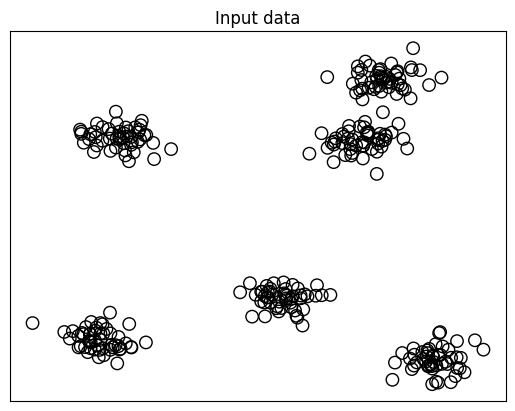

In [7]:
plt.figure()

plt.scatter(
    X[:, 0],
    X[:, 1],
    marker="o",
    facecolors="none",
    edgecolors="black",
    s=80
)

plt.title("Input data")
plt.xticks(())
plt.yticks(())

plt.show()

In [8]:
# Try different numbers of clusters
scores = []
values = np.arange(2, 10)

In [9]:
for num_clusters in values:
    kmeans = KMeans(
        init="k-means++",
        n_clusters=num_clusters,
        n_init=10,
        random_state=0
    )

    kmeans.fit(X)

    score = silhouette_score(
        X,
        kmeans.labels_,
        metric="euclidean"
    )

    scores.append(score)

    print("Number of clusters =", num_clusters)
    print("Silhouette score =", score)
    print()

Number of clusters = 2
Silhouette score = 0.6122994972540601

Number of clusters = 3
Silhouette score = 0.6264685067315234

Number of clusters = 4
Silhouette score = 0.7055637511499886

Number of clusters = 5
Silhouette score = 0.7871729198577987

Number of clusters = 6
Silhouette score = 0.781642733621281

Number of clusters = 7
Silhouette score = 0.7203367172498655

Number of clusters = 8
Silhouette score = 0.6473274964987348

Number of clusters = 9
Silhouette score = 0.5565787683262937



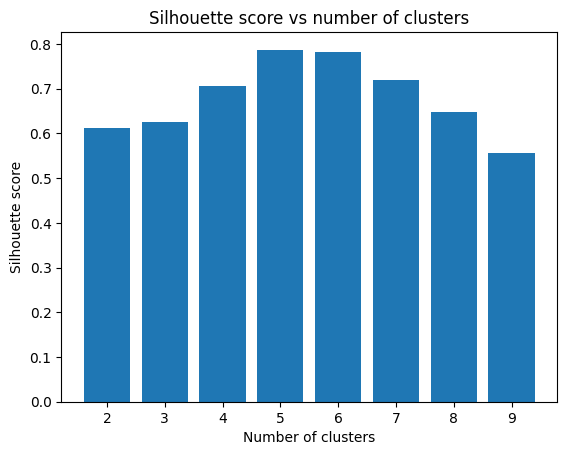

In [10]:
plt.figure()

plt.bar(values, scores)

plt.title("Silhouette score vs number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")

plt.show()

In [11]:
best_index = np.argmax(scores)
best_num_clusters = values[best_index]

print("Optimal number of clusters =", best_num_clusters)

Optimal number of clusters = 5
